# IB9LQ0 – Generative AI and AI Applications
## Required Task 3 – Image Classification with an MLP on Fashion-MNIST

**Module:** IB9LQ0 | Warwick Business School | 2025–2026

---

### Key Insights and Takeaways from Completing This Task

**Task Overview**

This task is a 'drop-in replacement' exercise — the MNIST image
classification blueprint from the tutorial is adapted to Fashion-MNIST
by changing a single line in the data loading step. The architecture,
training loop, and evaluation code remain structurally identical,
demonstrating the universality of the PyTorch workflow.

**Key Insight 1 – Why Fashion-MNIST is harder**

MNIST digits have very distinct shapes (a 7 looks nothing like a 3).
Fashion items share visual features — a shirt and a coat are both
rectangular garments. The model therefore achieves lower accuracy
, despite an identical architecture.
This shows that data complexity, not model size, is often the
limiting factor.

**Key Insight 2 – CrossEntropyLoss vs BCELoss**

Unlike Task 2 (binary: good/bad credit), this is a 10-class problem.
nn.CrossEntropyLoss is the correct loss function — it applies Softmax
internally and selects the class with the highest score. The model
therefore outputs raw logits (no final activation), which is different
from the Sigmoid output in Task 2.

**Key Insight 3 – The flattening trick**

Each image is a 28x28 pixel grid (a 3D tensor). An MLP needs a 1D
input vector. x.view(-1, 28*28) inside the forward() method
flattens each image into 784 numbers before passing it to the layers.

**Personal Takeaway**

Adapting the MNIST blueprint to Fashion-MNIST reinforced that the
PyTorch workflow is dataset-agnostic. The only meaningful change was
the dataset class name. Seeing the model correctly identify a sneaker
but confuse a coat with a shirt gave concrete intuition for where MLP
limitations lie — it discards all spatial pixel relationships by
flattening, which is why CNNs outperform MLPs on image tasks.

---
*AI Disclosure: Claude (Anthropic) was used to assist in structuring
this code. All outputs, interpretations, and conclusions were reviewed
and validated by the student.*

# Setup
PyTorch is pre-installed in Google Colab. The following confirms the version and GPU availability.

In [1]:
# Check PyTorch version and CUDA availability
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.10.0+cpu
CUDA available: False


# Complete Workflow: Image Classification with an MLP
## Fashion-MNIST — Clothing Item Classification

Fashion-MNIST is a drop-in replacement for the classic MNIST digit dataset.
It contains 70,000 grayscale images (60,000 training, 10,000 test),
each 28x28 pixels, across 10 clothing categories.

It is a harder problem than MNIST — clothing items share more visual
similarities than handwritten digits — making it a better benchmark
for evaluating model performance.

## Step 1: Loading and Preparing the Fashion-MNIST Dataset

PyTorch, through its `torchvision` library, makes it easy to download
and use standard datasets. The process is **identical to MNIST** —
the only change is `datasets.MNIST` → `datasets.FashionMNIST`.

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

# The 10 clothing categories in Fashion-MNIST.
# Index position matches the integer label the dataset assigns.
# Needed to display meaningful names instead of numbers in visualisations.
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# 1. Define a transformation
# `transforms.ToTensor()` converts the image into a PyTorch tensor
# and scales pixel values to be between 0 and 1.
# `transforms.Normalize()` adjusts the tensor values to have a mean
# of 0.5 and a standard deviation of 0.5. This helps stabilize training.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 2. Download and create datasets
# CHANGED FROM TUTORIAL: datasets.MNIST → datasets.FashionMNIST
# PyTorch will automatically download the data to the specified root directory.
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True,  transform=transform, download=True)
test_dataset  = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# 3. Create DataLoaders
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(dataset=test_dataset,  batch_size=64, shuffle=False)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")
print(f"Classes          : {class_names}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 228kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.25MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.4MB/s]

Training samples : 60000
Test samples     : 10000
Classes          : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## Step 2: Visualising the Data

It is always a good idea to look at a few examples from your dataset
to make sure everything is as you expect.

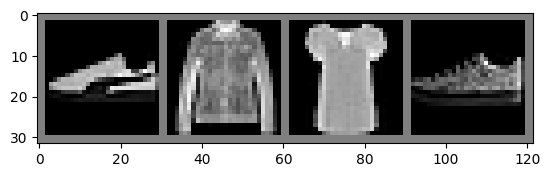

Labels: Sneaker Coat Shirt Sneaker


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Function to show an image
def imshow(img):
    img = img / 2 + 0.5  # Un-normalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Show the first 4 images from the batch
imshow(torchvision.utils.make_grid(images[:4]))
# Print the corresponding class names
print('Labels:', ' '.join(f'{class_names[labels[j]]}' for j in range(4)))

## Step 3: Defining and Training the Image Classification MLP

The model architecture is **reused directly from the tutorial** —
Fashion-MNIST has the same format as MNIST so the dimensions are identical:

* **Input layer size:** 784 (28 × 28 pixels, flattened inside `forward()`)
* **Output layer size:** 10 (one score per clothing class)

For multi-class classification, we use `nn.CrossEntropyLoss`. This loss
function is the standard for this type of problem and conveniently includes
the final Softmax activation within its calculation for better numerical
stability. Therefore, our model outputs raw scores (logits), not
probabilities — there is **no** Sigmoid at the end.

In [4]:
# Model Definition — reused directly from the tutorial ImageMLP
class ImageMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # The input layer size is 28*28 = 784
        self.layer1 = nn.Linear(784, 128)
        self.relu   = nn.ReLU()
        self.layer2 = nn.Linear(128, 64)
        # The output layer size is 10 for the 10 clothing classes
        self.layer3 = nn.Linear(64, 10)

    def forward(self, x):
        # The forward pass now includes flattening the image
        x = x.view(-1, 28 * 28)  # Flatten the image
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        # No final activation function here, as CrossEntropyLoss will apply it
        x = self.layer3(x)
        return x

model     = ImageMLP()
# Use CrossEntropyLoss for multi-class classification
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- Training Loop ---
# CHANGED FROM TUTORIAL: num_epochs = 5 → 10 (as specified in the task)
num_epochs = 10
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # Forward pass
        outputs = model(images)
        loss    = criterion(outputs, labels)

        # Backward and optimise
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

print("\nFinished Training!")

# --- Final Evaluation ---
model.eval()
with torch.no_grad():
    correct = 0
    total   = 0
    for images, labels in test_loader:
        outputs = model(images)
        # torch.max returns (value, index). We want the index (the predicted class)
        _, predicted = torch.max(outputs.data, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'Accuracy of the model on the 10,000 test images: {100 * correct / total:.2f}%')

Epoch [1/10], Step [100/938], Loss: 0.9282
Epoch [1/10], Step [200/938], Loss: 0.5367
Epoch [1/10], Step [300/938], Loss: 0.5555
Epoch [1/10], Step [400/938], Loss: 0.7522
Epoch [1/10], Step [500/938], Loss: 0.4136
Epoch [1/10], Step [600/938], Loss: 0.4589
Epoch [1/10], Step [700/938], Loss: 0.5832
Epoch [1/10], Step [800/938], Loss: 0.6758
Epoch [1/10], Step [900/938], Loss: 0.3733
Epoch [2/10], Step [100/938], Loss: 0.3075
Epoch [2/10], Step [200/938], Loss: 0.4028
Epoch [2/10], Step [300/938], Loss: 0.3628
Epoch [2/10], Step [400/938], Loss: 0.4764
Epoch [2/10], Step [500/938], Loss: 0.2480
Epoch [2/10], Step [600/938], Loss: 0.4357
Epoch [2/10], Step [700/938], Loss: 0.3040
Epoch [2/10], Step [800/938], Loss: 0.3364
Epoch [2/10], Step [900/938], Loss: 0.4096
Epoch [3/10], Step [100/938], Loss: 0.1732
Epoch [3/10], Step [200/938], Loss: 0.2316
Epoch [3/10], Step [300/938], Loss: 0.2913
Epoch [3/10], Step [400/938], Loss: 0.5675
Epoch [3/10], Step [500/938], Loss: 0.2543
Epoch [3/10

## Step 4: Displaying Predicted vs. Actual Outcomes

After training and evaluating the model, it is helpful to visualise a few
correct and incorrect predictions. This gives a clear sense of which
clothing items the model handles well and which ones it struggles with.

The following cell:
1. Iterates through the test data and collects all images, true labels,
   and predicted labels.
2. Identifies which predictions were correct and which were incorrect.
3. Randomly selects 5 examples from each group.
4. Displays correct predictions with titles in **green**.
5. Displays incorrect predictions with titles in **red**, showing both
   the actual clothing class and what the model predicted instead.

--- Examples of Correct Predictions ---


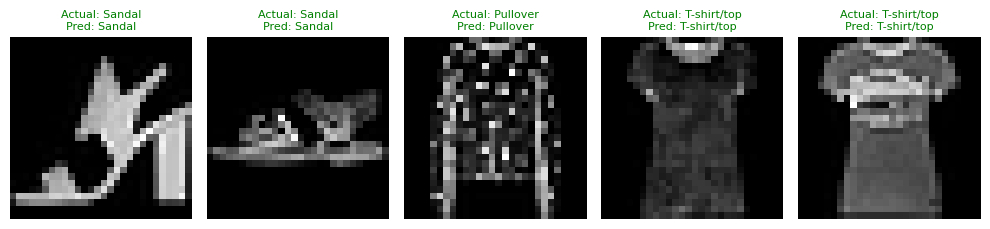


--- Examples of Incorrect Predictions ---


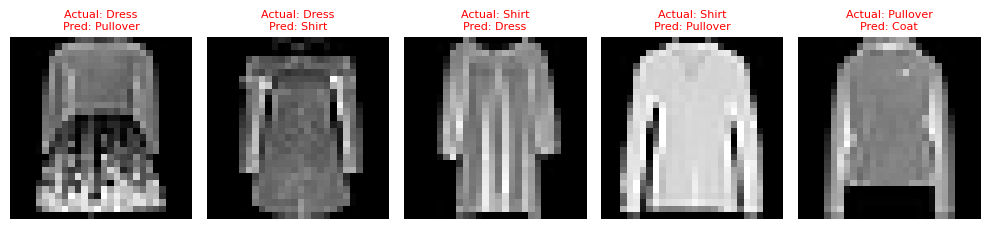

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Set the model to evaluation mode
model.eval()

# Disable gradient calculation
with torch.no_grad():
    all_images    = []
    all_labels    = []
    all_predicted = []

    # Iterate through the test data
    for images, labels in test_loader:
        # Get model outputs (logits)
        outputs = model(images)

        # Get predicted class (index of max logit)
        _, predicted = torch.max(outputs.data, 1)

        # Append to lists
        all_images.append(images)
        all_labels.append(labels)
        all_predicted.append(predicted)

# Concatenate all batches
all_images    = torch.cat(all_images)
all_labels    = torch.cat(all_labels)
all_predicted = torch.cat(all_predicted)

# Identify correct and incorrect predictions
correct_indices   = (all_predicted == all_labels).nonzero(as_tuple=True)[0]
incorrect_indices = (all_predicted != all_labels).nonzero(as_tuple=True)[0]

# Select 5 random correct and 5 random incorrect indices
num_examples_to_show = 5
if len(correct_indices) > num_examples_to_show:
    correct_sample_indices = correct_indices[torch.randperm(len(correct_indices))][:num_examples_to_show]
else:
    correct_sample_indices = correct_indices

if len(incorrect_indices) > num_examples_to_show:
    incorrect_sample_indices = incorrect_indices[torch.randperm(len(incorrect_indices))][:num_examples_to_show]
else:
    incorrect_sample_indices = incorrect_indices

# --- Display Correct Predictions ---
print("--- Examples of Correct Predictions ---")
plt.figure(figsize=(10, 4))
for i, idx in enumerate(correct_sample_indices):
    plt.subplot(1, num_examples_to_show, i + 1)
    # Un-normalize and reshape the image for plotting
    img = all_images[idx].squeeze() / 2 + 0.5
    plt.imshow(img.numpy(), cmap='gray')
    # CHANGED FROM TUTORIAL: show class name instead of number
    actual_name    = class_names[all_labels[idx].item()]
    predicted_name = class_names[all_predicted[idx].item()]
    plt.title(f"Actual: {actual_name}\nPred: {predicted_name}", color='green', fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

# --- Display Incorrect Predictions ---
print("\n--- Examples of Incorrect Predictions ---")
plt.figure(figsize=(10, 4))
for i, idx in enumerate(incorrect_sample_indices):
    plt.subplot(1, num_examples_to_show, i + 1)
    # Un-normalize and reshape the image for plotting
    img = all_images[idx].squeeze() / 2 + 0.5
    plt.imshow(img.numpy(), cmap='gray')
    # CHANGED FROM TUTORIAL: show class name instead of number
    actual_name    = class_names[all_labels[idx].item()]
    predicted_name = class_names[all_predicted[idx].item()]
    plt.title(f"Actual: {actual_name}\nPred: {predicted_name}", color='red', fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()